Inference time: 92.919 ms for one 640x640 image


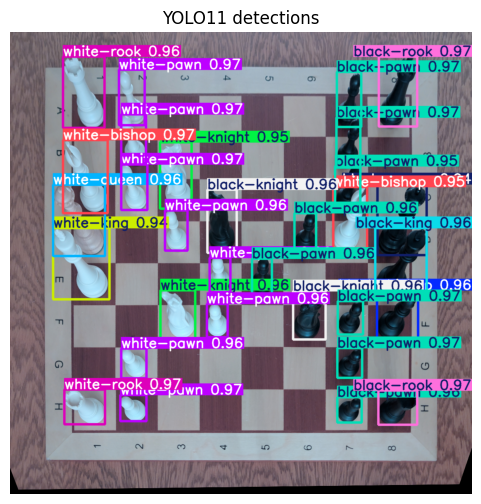

Detections:
black-rook: conf=0.973, box=(817.6, 54.6, 902.4, 209.4)
white-bishop: conf=0.971, box=(117.2, 239.6, 216.8, 401.2)
white-rook: conf=0.970, box=(120.2, 792.8, 210.2, 869.6)
white-pawn: conf=0.969, box=(241.4, 83.0, 298.2, 206.4)
black-pawn: conf=0.969, box=(724.0, 88.4, 778.4, 210.0)
black-pawn: conf=0.969, box=(726.8, 596.4, 782.0, 670.8)
white-pawn: conf=0.969, box=(244.0, 804.4, 302.0, 862.4)
white-pawn: conf=0.968, box=(246.2, 182.0, 301.0, 293.6)
black-pawn: conf=0.968, box=(723.2, 189.3, 776.0, 300.4)
black-pawn: conf=0.968, box=(725.6, 700.8, 780.0, 766.4)
white-pawn: conf=0.966, box=(246.4, 293.2, 304.0, 394.0)
black-rook: conf=0.965, box=(816.0, 794.0, 902.4, 870.4)
white-pawn: conf=0.965, box=(246.8, 701.6, 302.8, 767.2)
white-pawn: conf=0.964, box=(436.0, 602.8, 482.4, 676.4)
white-rook: conf=0.964, box=(117.6, 54.2, 209.2, 212.4)
white-pawn: conf=0.963, box=(343.6, 395.8, 393.2, 484.0)
black-pawn: conf=0.963, box=(725.6, 809.6, 779.2, 865.6)
black-king: conf=0.96

In [5]:
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# Paths
RUN_DIR = Path("./yolo11_runs/yolo11m_chess/weights")
WEIGHTS = RUN_DIR / "best.pt"

IMG_PATH = Path("./") / "game5_img_0014_warp.png"

assert WEIGHTS.exists(), f"Weights not found at {WEIGHTS}"
assert IMG_PATH.exists(), f"Image not found at {IMG_PATH}"

# Load model once
model = YOLO(str(WEIGHTS))

# Optional: fuse Conv + BatchNorm
try:
    model.fuse()
except Exception:
    pass

# Device and precision
use_cuda = torch.cuda.is_available()
device = 0 if use_cuda else "cpu"
half = use_cuda  # fp16 only on GPU

# Read image once
img_bgr = cv2.imread(str(IMG_PATH))
assert img_bgr is not None, "Could not read image"

# Warmup (not measured)
_ = model.predict(
    source=img_bgr,
    imgsz=640,
    device=device,
    half=half,
    conf=0.5,
    verbose=False,
)

# Timed inference
t0 = time.perf_counter()
results = model.predict(
    source=img_bgr,
    imgsz=640,
    device=device,
    half=half,
    conf=0.5,
    verbose=False,
)[0]
t1 = time.perf_counter()

inference_ms = (t1 - t0) * 1000
print(f"Inference time: {inference_ms:.3f} ms for one 640x640 image")

# Visualize
annotated = results.plot()  # BGR

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO11 detections")
plt.show()

# Optional: print detections
print("Detections:")
for box, cls_id, conf in zip(results.boxes.xyxy, results.boxes.cls, results.boxes.conf):
    x1, y1, x2, y2 = box.tolist()
    cls_name = model.names[int(cls_id)]
    print(f"{cls_name}: conf={conf:.3f}, box=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
